## Experiment 2 - Fitzpatrick17k Image XAI Disagreement

This notebook implements the image-based experiment for the final project. It fine-tunes a ResNet-18 on the Fitzpatrick17k `three_partiti` task, generates LIME, KernelSHAP, and Grad-CAM explanations on a bounded test subset, converts them into a shared superpixel attribution space, and compares disagreement overall and by skin group (`light` vs `dark`).

The notebook is organized to mirror the flow of Experiment 1: setup, data preparation, model training, explanation generation, disagreement metrics, subgroup analysis, visualization, and final write-up notes.


# Optional environment setup

Run the next cell only if your environment is missing one or more dependencies.


In [3]:
# Optional installs
# %pip install pandas numpy matplotlib seaborn scikit-learn pillow requests tqdm scipy
# %pip install torch torchvision
# %pip install lime shap scikit-image grad-cam


# Imports and configuration


In [4]:
import copy
import io
import math
import random
import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import requests
from PIL import Image
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import mannwhitneyu, spearmanr
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import torchvision
from torchvision import transforms

from skimage.segmentation import slic, mark_boundaries

from lime import lime_image
import shap

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "experiment2_data"
IMAGE_DIR = DATA_DIR / "images"
CACHE_DIR = DATA_DIR / "cache"
OUTPUT_DIR = PROJECT_ROOT / "experiment2_outputs"
for path in [DATA_DIR, IMAGE_DIR, CACHE_DIR, OUTPUT_DIR]:
    path.mkdir(parents=True, exist_ok=True)

FITZPATRICK17K_METADATA_URL = "https://raw.githubusercontent.com/mattgroh/fitzpatrick17k/main/fitzpatrick17k.csv"
METADATA_CACHE_PATH = CACHE_DIR / "fitzpatrick17k.csv"
DOWNLOAD_LOG_PATH = OUTPUT_DIR / "download_log.csv"
CLEAN_METADATA_PATH = OUTPUT_DIR / "fitzpatrick17k_cleaned.csv"
ATTRIBUTION_PATH = OUTPUT_DIR / "attributions_long.csv"
METRICS_PATH = OUTPUT_DIR / "metrics_long.csv"

IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 0
HEAD_EPOCHS = 2
FINETUNE_EPOCHS = 4
PATIENCE = 2
LEARNING_RATE_HEAD = 1e-3
LEARNING_RATE_FINETUNE = 1e-4
WEIGHT_DECAY = 1e-4

MAX_EXPLANATION_IMAGES = 24
SUPERPIXEL_COUNT = 20
SUPERPIXEL_COMPACTNESS = 12
LIME_NUM_SAMPLES = 400
SHAP_NUM_SAMPLES = 300
TOP_K_VALUES = [3, 5, 10]

print("Outputs will be saved under:", OUTPUT_DIR)


/opt/anaconda3/envs/2028_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu
Outputs will be saved under: /Users/andrewyuyy/Desktop/2028FinalProject/experiment2_outputs


# Dataset metadata acquisition

The original Fitzpatrick17k repository publishes the metadata CSV, and the README states that the image source links are stored in the `url` column. This notebook downloads that metadata file and then uses the image URLs to build a local cache.


In [5]:
def download_file(url, destination, chunk_size=1 << 14):
    response = requests.get(url, stream=True, timeout=60)
    response.raise_for_status()
    with open(destination, "wb") as f:
        for chunk in response.iter_content(chunk_size=chunk_size):
            if chunk:
                f.write(chunk)


if not METADATA_CACHE_PATH.exists():
    download_file(FITZPATRICK17K_METADATA_URL, METADATA_CACHE_PATH)

raw_df = pd.read_csv(METADATA_CACHE_PATH)
print(raw_df.shape)
raw_df.head()


(16577, 9)


,md5hash,fitzpatrick_scale,fitzpatrick_centaur,label,nine_partition_label,three_partition_label,qc,url,url_alphanum
0,5e82a45bc5d78bd24ae9202d194423f8,3,3,drug induced pigmentary changes,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicmminoc...
1,fa2911a9b13b6f8af79cb700937cc14f,1,1,photodermatoses,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicpphoto...
2,d2bac3c9e4499032ca8e9b07c7d3bc40,2,3,dermatofibroma,benign dermal,benign,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicdderma...
3,0a94359e7eaacd7178e06b2823777789,1,1,psoriasis,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicppsori...
4,a39ec3b1f22c08a421fa20535e037bba,1,1,psoriasis,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicppsori...


# Metadata cleaning

The dataset has appeared with slightly different column names across mirrors and follow-up analysis work. The helper below normalizes the key fields so the rest of the notebook can use a stable schema.


In [6]:
def first_existing_column(df, candidates):
    for column in candidates:
        if column in df.columns:
            return column
    raise KeyError(f"None of the candidate columns were found: {candidates}")


def normalize_metadata(df):
    df = df.copy()

    fitz_col = first_existing_column(df, ["fitzpatrick_sc", "fitzpatrick", "fitzpatrick_scale"])
    target_col = first_existing_column(df, ["three_partiti", "three_partition_label", "three_partition", "three_partition_labels"])
    url_col = first_existing_column(df, ["url", "image_url"])
    image_id_col = next((c for c in ["md5hash", "image_id", "new_img_name", "orig_img_name"] if c in df.columns), None)

    normalized = pd.DataFrame({
        "fitzpatrick_sc": pd.to_numeric(df[fitz_col], errors="coerce"),
        "three_partiti": df[target_col].astype(str).str.strip(),
        "image_url": df[url_col].astype(str).str.strip(),
    })

    if image_id_col is not None:
        normalized["image_id"] = df[image_id_col].astype(str).str.strip()
    else:
        normalized["image_id"] = [f"img_{idx:05d}" for idx in range(len(df))]

    normalized["image_id"] = normalized["image_id"].replace({"": np.nan})
    missing_ids = normalized["image_id"].isna()
    normalized.loc[missing_ids, "image_id"] = [f"img_{idx:05d}" for idx in normalized.index[missing_ids]]
    normalized["fitzpatrick_sc"] = normalized["fitzpatrick_sc"].astype("Int64")
    return normalized


metadata = normalize_metadata(raw_df)
metadata["skin_group"] = metadata["fitzpatrick_sc"].map({1: "light", 2: "light", 5: "dark", 6: "dark"})
metadata = metadata[
    metadata["fitzpatrick_sc"].isin([1, 2, 5, 6])
    & metadata["three_partiti"].notna()
    & (metadata["three_partiti"].astype(str).str.len() > 0)
    & metadata["image_url"].notna()
    & metadata["image_url"].str.startswith("http")
].copy()

metadata["local_image_path"] = metadata["image_id"].apply(lambda x: str(IMAGE_DIR / f"{x}.jpg"))
metadata = metadata.reset_index(drop=True)

print("Rows after label and demographic filtering:", len(metadata))
display(metadata.head())
display(metadata.groupby(["skin_group", "three_partiti"]).size().sort_values(ascending=False).head(12).rename("count").reset_index())


Rows after label and demographic filtering: 9897


,fitzpatrick_sc,three_partiti,image_url,image_id,skin_group,local_image_path
0,1,non-neoplastic,https://www.dermaamin.com/site/images/clinical...,fa2911a9b13b6f8af79cb700937cc14f,light,/Users/andrewyuyy/Desktop/2028FinalProject/exp...
1,2,benign,https://www.dermaamin.com/site/images/clinical...,d2bac3c9e4499032ca8e9b07c7d3bc40,light,/Users/andrewyuyy/Desktop/2028FinalProject/exp...
2,1,non-neoplastic,https://www.dermaamin.com/site/images/clinical...,0a94359e7eaacd7178e06b2823777789,light,/Users/andrewyuyy/Desktop/2028FinalProject/exp...
3,1,non-neoplastic,https://www.dermaamin.com/site/images/clinical...,a39ec3b1f22c08a421fa20535e037bba,light,/Users/andrewyuyy/Desktop/2028FinalProject/exp...
4,6,malignant,https://www.dermaamin.com/site/images/clinical...,45f7fe0e10214e32e890cad9d29d4811,dark,/Users/andrewyuyy/Desktop/2028FinalProject/exp...


,skin_group,three_partiti,count
0,light,non-neoplastic,5431
1,dark,non-neoplastic,1749
2,light,malignant,1195
3,light,benign,1113
4,dark,malignant,206
5,dark,benign,203


# Image download and cache validation

Some source URLs are broken in Fitzpatrick17k. This step downloads what is still accessible, validates each image, and records failures so the final modeling cohort is reproducible.


In [7]:
def infer_extension_from_response(response):
    content_type = response.headers.get("content-type", "").lower()
    if "png" in content_type:
        return ".png"
    if "webp" in content_type:
        return ".webp"
    return ".jpg"


def validate_and_convert_image(raw_bytes, destination):
    image = Image.open(io.BytesIO(raw_bytes)).convert("RGB")
    image.save(destination, format="JPEG", quality=95)
    return image.size


def download_and_validate_images(df):
    logs = []
    for row in tqdm(df.itertuples(index=False), total=len(df), desc="Downloading images"):
        destination = Path(row.local_image_path)
        status = "cached"
        width = None
        height = None
        error_message = ""

        try:
            if destination.exists():
                with Image.open(destination) as image:
                    image = image.convert("RGB")
                    width, height = image.size
            else:
                response = requests.get(row.image_url, timeout=30)
                response.raise_for_status()
                width, height = validate_and_convert_image(response.content, destination)
                status = "downloaded"
        except Exception as exc:
            status = "failed"
            error_message = str(exc)[:300]
            if destination.exists():
                destination.unlink(missing_ok=True)

        logs.append({
            "image_id": row.image_id,
            "image_url": row.image_url,
            "local_image_path": str(destination),
            "status": status,
            "width": width,
            "height": height,
            "error_message": error_message,
        })

    return pd.DataFrame(logs)


download_log = download_and_validate_images(metadata)
download_log.to_csv(DOWNLOAD_LOG_PATH, index=False)

usable_ids = set(download_log.loc[download_log["status"].isin(["cached", "downloaded"]), "image_id"])
metadata = metadata[metadata["image_id"].isin(usable_ids)].copy().reset_index(drop=True)
metadata.to_csv(CLEAN_METADATA_PATH, index=False)

print(download_log["status"].value_counts(dropna=False))
print("Usable images:", len(metadata))


status
failed    8241
cached    1656
Name: count, dtype: int64
Usable images: 1656


# Train/validation/test split and preprocessing

In [8]:
label_names = sorted(metadata["three_partiti"].unique())
label_to_idx = {label: idx for idx, label in enumerate(label_names)}
idx_to_label = {idx: label for label, idx in label_to_idx.items()}
metadata["label_idx"] = metadata["three_partiti"].map(label_to_idx)

train_df, temp_df = train_test_split(
    metadata,
    test_size=0.30,
    stratify=metadata["label_idx"],
    random_state=SEED,
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label_idx"],
    random_state=SEED,
)

for split_name, split_df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    metadata.loc[split_df.index, "split"] = split_name

metadata.to_csv(CLEAN_METADATA_PATH, index=False)

display(metadata.groupby(["split", "skin_group"]).size().rename("count").reset_index())
display(metadata.groupby(["split", "three_partiti"]).size().rename("count").reset_index().head(15))

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


class FitzpatrickImageDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True).copy()
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image = Image.open(row["local_image_path"]).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)
        return {
            "image": image,
            "label": int(row["label_idx"]),
            "image_id": row["image_id"],
            "skin_group": row["skin_group"],
            "path": row["local_image_path"],
        }


def collate_batch(batch):
    return {
        "image": torch.stack([item["image"] for item in batch]),
        "label": torch.tensor([item["label"] for item in batch], dtype=torch.long),
        "image_id": [item["image_id"] for item in batch],
        "skin_group": [item["skin_group"] for item in batch],
        "path": [item["path"] for item in batch],
    }


train_dataset = FitzpatrickImageDataset(train_df, transform=train_transform)
val_dataset = FitzpatrickImageDataset(val_df, transform=eval_transform)
test_dataset = FitzpatrickImageDataset(test_df, transform=eval_transform)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(len(label_names)),
    y=train_df["label_idx"],
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)

sample_weights = train_df["label_idx"].map({i: float(class_weights[i]) for i in range(len(class_weights))}).values
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=NUM_WORKERS, collate_fn=collate_batch)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=collate_batch)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=collate_batch)


,split,skin_group,count
0,test,dark,128
1,test,light,121
2,train,dark,558
3,train,light,601
4,val,dark,151
5,val,light,97


,split,three_partiti,count
0,test,benign,19
1,test,malignant,48
2,test,non-neoplastic,182
3,train,benign,89
4,train,malignant,224
5,train,non-neoplastic,846
6,val,benign,19
7,val,malignant,48
8,val,non-neoplastic,181


# ResNet-18 training
Train the classifier head first, then fine-tune the full model.

In [9]:
def build_resnet18(num_classes):
    try:
        weights = torchvision.models.ResNet18_Weights.DEFAULT
        model = torchvision.models.resnet18(weights=weights)
    except AttributeError:
        model = torchvision.models.resnet18(pretrained=True)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


def freeze_backbone(model):
    for name, param in model.named_parameters():
        param.requires_grad = name.startswith("fc")


def unfreeze_all(model):
    for param in model.parameters():
        param.requires_grad = True


def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

    running_loss = 0.0
    all_labels = []
    all_preds = []

    for batch in loader:
        inputs = batch["image"].to(DEVICE)
        labels = batch["label"].to(DEVICE)

        if is_train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):
            logits = model(inputs)
            loss = criterion(logits, labels)
            if is_train:
                loss.backward()
                optimizer.step()

        running_loss += loss.item() * len(labels)
        preds = logits.argmax(dim=1)
        all_labels.extend(labels.detach().cpu().numpy())
        all_preds.extend(preds.detach().cpu().numpy())

    epoch_loss = running_loss / max(len(loader.dataset), 1)
    epoch_acc = accuracy_score(all_labels, all_preds)
    return epoch_loss, epoch_acc


model = build_resnet18(len(label_names)).to(DEVICE)
history = []
best_state = None
best_val_acc = -np.inf
epochs_without_improvement = 0

freeze_backbone(model)
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LEARNING_RATE_HEAD, weight_decay=WEIGHT_DECAY)

for epoch in range(HEAD_EPOCHS):
    train_loss, train_acc = run_epoch(model, train_loader, optimizer=optimizer)
    val_loss, val_acc = run_epoch(model, val_loader, optimizer=None)
    history.append({"phase": "head", "epoch": epoch + 1, "train_loss": train_loss, "train_acc": train_acc, "val_loss": val_loss, "val_acc": val_acc})
    print(f"[head] epoch={epoch + 1} train_acc={train_acc:.4f} val_acc={val_acc:.4f}")
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = copy.deepcopy(model.state_dict())

unfreeze_all(model)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE_FINETUNE, weight_decay=WEIGHT_DECAY)

for epoch in range(FINETUNE_EPOCHS):
    train_loss, train_acc = run_epoch(model, train_loader, optimizer=optimizer)
    val_loss, val_acc = run_epoch(model, val_loader, optimizer=None)
    history.append({"phase": "finetune", "epoch": epoch + 1, "train_loss": train_loss, "train_acc": train_acc, "val_loss": val_loss, "val_acc": val_acc})
    print(f"[finetune] epoch={epoch + 1} train_acc={train_acc:.4f} val_acc={val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= PATIENCE:
            print("Early stopping triggered.")
            break

if best_state is not None:
    model.load_state_dict(best_state)

history_df = pd.DataFrame(history)
history_df


[head] epoch=1 train_acc=0.3883 val_acc=0.1573
[head] epoch=2 train_acc=0.4582 val_acc=0.1653
[finetune] epoch=1 train_acc=0.6670 val_acc=0.6411
[finetune] epoch=2 train_acc=0.8576 val_acc=0.7460
[finetune] epoch=3 train_acc=0.9448 val_acc=0.7661
[finetune] epoch=4 train_acc=0.9612 val_acc=0.8226


,phase,epoch,train_loss,train_acc,val_loss,val_acc
0,head,1,0.837356,0.388266,1.234456,0.157258
1,head,2,0.694843,0.458154,1.234933,0.165323
2,finetune,1,0.367794,0.666954,1.035424,0.641129
3,finetune,2,0.135949,0.857636,1.146350,0.745968
4,finetune,3,0.057526,0.944780,1.091019,0.766129
5,finetune,4,0.037854,0.961173,1.474649,0.822581


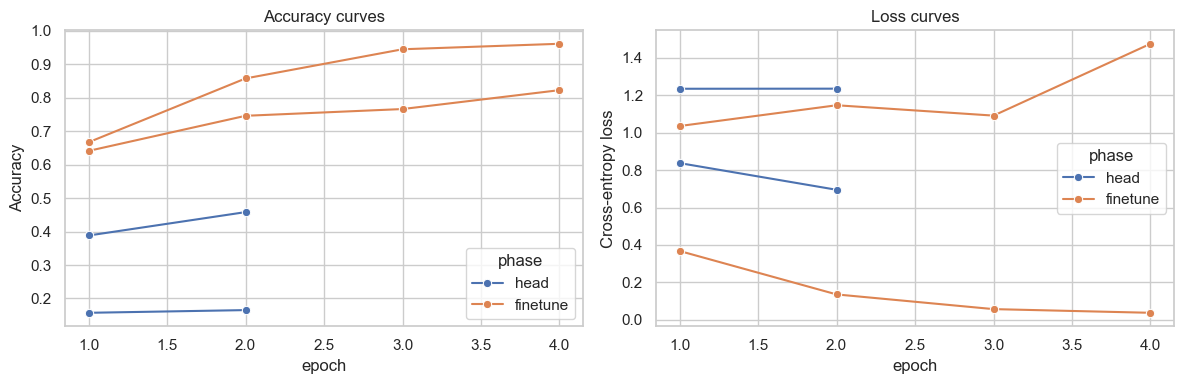

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.lineplot(data=history_df, x="epoch", y="train_acc", hue="phase", marker="o", ax=axes[0], legend=False)
sns.lineplot(data=history_df, x="epoch", y="val_acc", hue="phase", marker="o", ax=axes[0])
axes[0].set_title("Accuracy curves")
axes[0].set_ylabel("Accuracy")

sns.lineplot(data=history_df, x="epoch", y="train_loss", hue="phase", marker="o", ax=axes[1], legend=False)
sns.lineplot(data=history_df, x="epoch", y="val_loss", hue="phase", marker="o", ax=axes[1])
axes[1].set_title("Loss curves")
axes[1].set_ylabel("Cross-entropy loss")
plt.tight_layout()


# Evaluation on the fixed test set


Overall test accuracy: 0.8313


,skin_group,count,accuracy
0,dark,128.0,0.843750
1,light,121.0,0.818182


                precision    recall  f1-score   support

        benign       0.44      0.42      0.43        19
     malignant       0.74      0.81      0.77        48
non-neoplastic       0.90      0.88      0.89       182

      accuracy                           0.83       249
     macro avg       0.69      0.70      0.70       249
  weighted avg       0.83      0.83      0.83       249



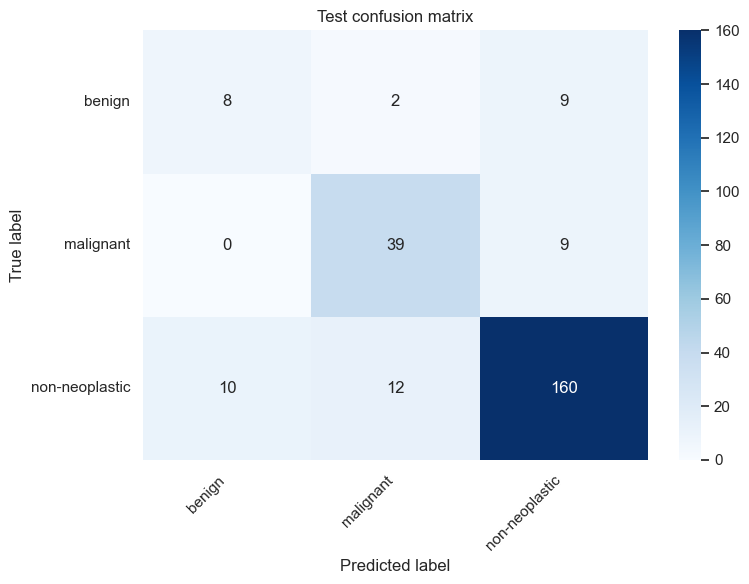

In [11]:
def predict_loader(model, loader):
    model.eval()
    records = []
    with torch.no_grad():
        for batch in loader:
            inputs = batch["image"].to(DEVICE)
            logits = model(inputs)
            probs = torch.softmax(logits, dim=1)
            preds = probs.argmax(dim=1).cpu().numpy()
            confidences = probs.max(dim=1).values.cpu().numpy()
            for i in range(len(preds)):
                records.append({
                    "image_id": batch["image_id"][i],
                    "skin_group": batch["skin_group"][i],
                    "true_label_idx": int(batch["label"][i].item()),
                    "pred_label_idx": int(preds[i]),
                    "confidence": float(confidences[i]),
                    "path": batch["path"][i],
                })
    return pd.DataFrame(records)


test_predictions = predict_loader(model, test_loader)
test_predictions["true_label"] = test_predictions["true_label_idx"].map(idx_to_label)
test_predictions["pred_label"] = test_predictions["pred_label_idx"].map(idx_to_label)

overall_acc = accuracy_score(test_predictions["true_label_idx"], test_predictions["pred_label_idx"])
print("Overall test accuracy:", round(overall_acc, 4))

display(test_predictions.groupby("skin_group").apply(lambda g: pd.Series({"count": len(g), "accuracy": accuracy_score(g["true_label_idx"], g["pred_label_idx"])})).reset_index())

print(classification_report(test_predictions["true_label_idx"], test_predictions["pred_label_idx"], target_names=label_names, zero_division=0))

cm = confusion_matrix(test_predictions["true_label_idx"], test_predictions["pred_label_idx"])
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_names, yticklabels=label_names)
plt.title("Test confusion matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()


# Explanation subset selection and superpixel helpers

The explanation stage is intentionally capped so the experiment stays feasible on local hardware. We sample a balanced subset across skin group and predicted class whenever possible.


In [12]:
def select_explanation_subset(predictions_df, max_images=MAX_EXPLANATION_IMAGES):
    grouped = predictions_df.groupby(["skin_group", "pred_label"], group_keys=False)
    group_count = max(len(grouped), 1)
    per_group = max(1, max_images // group_count)
    sampled = grouped.apply(lambda g: g.sample(n=min(len(g), per_group), random_state=SEED))
    sampled = sampled.drop_duplicates(subset=["image_id"]).copy()
    if len(sampled) < min(max_images, len(predictions_df)):
        remaining = predictions_df.loc[~predictions_df["image_id"].isin(sampled["image_id"])]
        top_up = remaining.sample(n=min(len(remaining), max_images - len(sampled)), random_state=SEED)
        sampled = pd.concat([sampled, top_up], ignore_index=True)
    return sampled.head(max_images).reset_index(drop=True)


explain_df = select_explanation_subset(test_predictions, max_images=MAX_EXPLANATION_IMAGES)
display(explain_df.groupby(["skin_group", "pred_label"]).size().rename("count").reset_index())

imagenet_mean = np.array([0.485, 0.456, 0.406])
imagenet_std = np.array([0.229, 0.224, 0.225])


def load_image_rgb(path):
    return np.array(Image.open(path).convert("RGB").resize((IMAGE_SIZE, IMAGE_SIZE)))


def preprocess_numpy_images(images_np):
    tensors = []
    for image_np in images_np:
        image = Image.fromarray(image_np.astype(np.uint8))
        tensors.append(eval_transform(image))
    return torch.stack(tensors).to(DEVICE)


def model_predict_numpy(images_np):
    model.eval()
    images_np = np.asarray(images_np)
    if images_np.ndim == 3:
        images_np = np.expand_dims(images_np, axis=0)
    with torch.no_grad():
        logits = model(preprocess_numpy_images(images_np))
        probs = torch.softmax(logits, dim=1).cpu().numpy()
    return probs


def make_superpixels(image_np, n_segments=SUPERPIXEL_COUNT, compactness=SUPERPIXEL_COMPACTNESS):
    return slic(image_np, n_segments=n_segments, compactness=compactness, start_label=0)


def mask_with_segments(image_np, segments, coalition, baseline=None):
    masked = image_np.copy()
    if baseline is None:
        baseline = np.full_like(image_np, image_np.mean(axis=(0, 1), keepdims=True), dtype=np.uint8)
    for superpixel_id, keep in enumerate(coalition):
        if keep < 0.5:
            masked[segments == superpixel_id] = baseline[segments == superpixel_id]
    return masked


def overlay_segment_scores(image_np, segments, scores, cmap="coolwarm"):
    score_map = np.zeros(segments.shape, dtype=float)
    for segment_id, score in enumerate(scores):
        score_map[segments == segment_id] = score
    return score_map


,skin_group,pred_label,count
0,dark,benign,4
1,dark,malignant,4
2,dark,non-neoplastic,4
3,light,benign,4
4,light,malignant,4
5,light,non-neoplastic,4


# LIME explanations


In [13]:
lime_explainer = lime_image.LimeImageExplainer(random_state=SEED)


def explain_with_lime(image_np, segments, target_class):
    explanation = lime_explainer.explain_instance(
        image=image_np.astype(np.double),
        classifier_fn=model_predict_numpy,
        labels=(target_class,),
        top_labels=None,
        hide_color=0,
        num_samples=LIME_NUM_SAMPLES,
        segmentation_fn=lambda _: segments,
    )
    scores = np.zeros(int(segments.max()) + 1, dtype=float)
    for segment_id, weight in explanation.local_exp[target_class]:
        scores[segment_id] = weight
    return scores, explanation


# KernelSHAP explanations

To keep the image experiment feasible, each image is explained in a superpixel feature space. A coalition vector indicates which superpixels remain visible and which are replaced with a simple baseline.


In [14]:
def explain_with_kernel_shap(image_np, segments, target_class, nsamples=SHAP_NUM_SAMPLES):
    num_superpixels = int(segments.max()) + 1
    baseline = np.full_like(image_np, image_np.mean(axis=(0, 1), keepdims=True), dtype=np.uint8)

    def shap_predict(mask_matrix):
        mask_matrix = np.asarray(mask_matrix)
        if mask_matrix.ndim == 1:
            mask_matrix = mask_matrix.reshape(1, -1)
        masked_images = [mask_with_segments(image_np, segments, coalition, baseline=baseline) for coalition in mask_matrix]
        probabilities = model_predict_numpy(np.stack(masked_images))[:, target_class]
        return probabilities

    background = np.zeros((1, num_superpixels), dtype=float)
    explainer = shap.KernelExplainer(shap_predict, background)
    shap_values = explainer.shap_values(np.ones((1, num_superpixels), dtype=float), nsamples=nsamples)
    shap_values = np.asarray(shap_values)
    if shap_values.ndim == 2:
        scores = shap_values[0]
    else:
        scores = shap_values.squeeze()
    return np.asarray(scores, dtype=float)


# Grad-CAM explanations


In [15]:
grad_cam = GradCAM(model=model, target_layers=[model.layer4[-1]])


def explain_with_gradcam(image_np, segments, target_class):
    input_tensor = preprocess_numpy_images(np.expand_dims(image_np, axis=0))
    grayscale_cam = grad_cam(input_tensor=input_tensor, targets=[ClassifierOutputTarget(target_class)])[0]
    num_superpixels = int(segments.max()) + 1
    scores = np.zeros(num_superpixels, dtype=float)
    for segment_id in range(num_superpixels):
        region = grayscale_cam[segments == segment_id]
        scores[segment_id] = float(region.mean()) if len(region) else 0.0
    return scores, grayscale_cam


# Unified attribution table

The next cell generates all three explanation types for the bounded subset and stores the results in a single long-form table keyed by `image_id` and `superpixel_id`.


In [16]:
all_attribution_rows = []
visual_cache = {}

for row in tqdm(explain_df.itertuples(index=False), total=len(explain_df), desc="Generating explanations"):
    image_np = load_image_rgb(row.path)
    segments = make_superpixels(image_np)
    num_superpixels = int(segments.max()) + 1

    lime_scores, lime_obj = explain_with_lime(image_np, segments, row.pred_label_idx)
    shap_scores = explain_with_kernel_shap(image_np, segments, row.pred_label_idx)
    gradcam_scores, gradcam_map = explain_with_gradcam(image_np, segments, row.pred_label_idx)

    visual_cache[row.image_id] = {
        "image": image_np,
        "segments": segments,
        "lime_scores": lime_scores,
        "shap_scores": shap_scores,
        "gradcam_scores": gradcam_scores,
        "gradcam_map": gradcam_map,
        "pred_label": row.pred_label,
        "true_label": row.true_label,
    }

    for superpixel_id in range(num_superpixels):
        all_attribution_rows.append({
            "image_id": row.image_id,
            "skin_group": row.skin_group,
            "true_label": row.true_label,
            "pred_label": row.pred_label,
            "superpixel_id": superpixel_id,
            "lime_score": float(lime_scores[superpixel_id]),
            "shap_score": float(shap_scores[superpixel_id]),
            "gradcam_score": float(gradcam_scores[superpixel_id]),
        })

attributions_df = pd.DataFrame(all_attribution_rows)
attributions_df.to_csv(ATTRIBUTION_PATH, index=False)
attributions_df.head()


Generating explanations: 100%|██████████| 24/24 [03:32<00:00,  8.86s/it]


,image_id,skin_group,true_label,pred_label,superpixel_id,lime_score,shap_score,gradcam_score
0,04da9d1ff1c84ad7ba9525cc49b306af,dark,non-neoplastic,benign,0,0.005417,0.000000,0.318823
1,04da9d1ff1c84ad7ba9525cc49b306af,dark,non-neoplastic,benign,1,0.006150,0.000000,0.050179
2,04da9d1ff1c84ad7ba9525cc49b306af,dark,non-neoplastic,benign,2,0.005875,0.055000,0.079939
3,04da9d1ff1c84ad7ba9525cc49b306af,dark,non-neoplastic,benign,3,0.014616,0.057257,0.111498
4,04da9d1ff1c84ad7ba9525cc49b306af,dark,non-neoplastic,benign,4,0.002929,0.000000,0.057525


# Disagreement metrics (Krishna-style adaptations)

These helpers adapt the feature/rank/sign comparison logic used in Experiment 1 to the image superpixel setting.


In [17]:
def safe_topk(k, length):
    return max(1, min(k, length))


def get_topk_indices(explanation, k):
    k = safe_topk(k, len(explanation))
    return np.argsort(-np.abs(explanation))[:k]


def feature_agreement(a, b, k):
    top_a = set(get_topk_indices(a, k))
    top_b = set(get_topk_indices(b, k))
    return len(top_a & top_b) / safe_topk(k, min(len(a), len(b)))


def rank_agreement(a, b, k):
    top_a = get_topk_indices(a, k)
    top_b = get_topk_indices(b, k)
    k = safe_topk(k, min(len(top_a), len(top_b)))
    return float(np.mean(top_a[:k] == top_b[:k]))


def sign_agreement(a, b, k):
    shared = list(set(get_topk_indices(a, k)) & set(get_topk_indices(b, k)))
    if not shared:
        return np.nan
    return float(np.mean(np.sign(a[shared]) == np.sign(b[shared])))


def signed_rank_agreement(a, b, k):
    top_a = get_topk_indices(a, k)
    top_b = get_topk_indices(b, k)
    k = safe_topk(k, min(len(top_a), len(top_b)))
    matches = []
    for idx in range(k):
        same_feature = top_a[idx] == top_b[idx]
        same_sign = np.sign(a[top_a[idx]]) == np.sign(b[top_b[idx]])
        matches.append(float(same_feature and same_sign))
    return float(np.mean(matches)) if matches else np.nan


def rank_correlation(a, b):
    ranks_a = np.argsort(np.argsort(-np.abs(a)))
    ranks_b = np.argsort(np.argsort(-np.abs(b)))
    corr, _ = spearmanr(ranks_a, ranks_b)
    return float(corr) if not np.isnan(corr) else 0.0


def pairwise_rank_agreement(a, b):
    agreements = []
    for i in range(len(a)):
        for j in range(i + 1, len(a)):
            order_a = np.abs(a[i]) >= np.abs(a[j])
            order_b = np.abs(b[i]) >= np.abs(b[j])
            agreements.append(float(order_a == order_b))
    return float(np.mean(agreements)) if agreements else np.nan


toy_a = np.array([0.9, 0.4, -0.2, 0.1])
toy_b = np.array([0.8, 0.3, -0.5, 0.05])
print("Synthetic metric smoke test:")
print("feature_agreement@3:", feature_agreement(toy_a, toy_b, 3))
print("rank_agreement@3:", rank_agreement(toy_a, toy_b, 3))
print("sign_agreement@3:", sign_agreement(toy_a, toy_b, 3))
print("rank_correlation:", rank_correlation(toy_a, toy_b))
print("pairwise_rank_agreement:", pairwise_rank_agreement(toy_a, toy_b))


Synthetic metric smoke test:
feature_agreement@3: 1.0
rank_agreement@3: 0.3333333333333333
sign_agreement@3: 1.0
rank_correlation: 0.7999999999999999
pairwise_rank_agreement: 0.8333333333333334


In [18]:
pair_specs = {
    ("lime", "shap"): ["feature_agreement", "rank_agreement", "sign_agreement", "signed_rank_agreement", "rank_correlation", "pairwise_rank_agreement"],
    ("lime", "gradcam"): ["feature_agreement", "rank_agreement", "rank_correlation", "pairwise_rank_agreement"],
    ("shap", "gradcam"): ["feature_agreement", "rank_agreement", "rank_correlation", "pairwise_rank_agreement"],
}

metric_functions = {
    "feature_agreement": feature_agreement,
    "rank_agreement": rank_agreement,
    "sign_agreement": sign_agreement,
    "signed_rank_agreement": signed_rank_agreement,
    "rank_correlation": lambda a, b, k=None: rank_correlation(a, b),
    "pairwise_rank_agreement": lambda a, b, k=None: pairwise_rank_agreement(a, b),
}

metric_rows = []
for image_id, group_df in attributions_df.groupby("image_id"):
    group_df = group_df.sort_values("superpixel_id")
    scores = {
        "lime": group_df["lime_score"].to_numpy(),
        "shap": group_df["shap_score"].to_numpy(),
        "gradcam": group_df["gradcam_score"].to_numpy(),
    }
    skin_group = group_df["skin_group"].iloc[0]

    for (explainer_a, explainer_b), metrics in pair_specs.items():
        a = scores[explainer_a]
        b = scores[explainer_b]

        for metric_name in metrics:
            if metric_name in {"rank_correlation", "pairwise_rank_agreement"}:
                score = metric_functions[metric_name](a, b)
                metric_rows.append({
                    "image_id": image_id,
                    "skin_group": skin_group,
                    "explainer_a": explainer_a,
                    "explainer_b": explainer_b,
                    "metric": metric_name,
                    "k": np.nan,
                    "score": score,
                })
            else:
                for k in TOP_K_VALUES:
                    score = metric_functions[metric_name](a, b, k)
                    metric_rows.append({
                        "image_id": image_id,
                        "skin_group": skin_group,
                        "explainer_a": explainer_a,
                        "explainer_b": explainer_b,
                        "metric": metric_name,
                        "k": k,
                        "score": score,
                    })

metrics_df = pd.DataFrame(metric_rows)
metrics_df.to_csv(METRICS_PATH, index=False)
metrics_df.head()


,image_id,skin_group,explainer_a,explainer_b,metric,k,score
0,04da9d1ff1c84ad7ba9525cc49b306af,dark,lime,shap,feature_agreement,3.0,0.333333
1,04da9d1ff1c84ad7ba9525cc49b306af,dark,lime,shap,feature_agreement,5.0,0.600000
2,04da9d1ff1c84ad7ba9525cc49b306af,dark,lime,shap,feature_agreement,10.0,0.900000
3,04da9d1ff1c84ad7ba9525cc49b306af,dark,lime,shap,rank_agreement,3.0,0.333333
4,04da9d1ff1c84ad7ba9525cc49b306af,dark,lime,shap,rank_agreement,5.0,0.200000


# Subgroup statistics and significance tests


In [19]:
summary_df = (
    metrics_df
    .groupby(["skin_group", "explainer_a", "explainer_b", "metric", "k"], dropna=False)
    .agg(mean_score=("score", "mean"), se_score=("score", lambda x: np.nanstd(x, ddof=1) / math.sqrt(max(x.notna().sum(), 1))), count=("score", "count"))
    .reset_index()
)

overall_summary_df = (
    metrics_df
    .groupby(["explainer_a", "explainer_b", "metric", "k"], dropna=False)
    .agg(mean_score=("score", "mean"), se_score=("score", lambda x: np.nanstd(x, ddof=1) / math.sqrt(max(x.notna().sum(), 1))), count=("score", "count"))
    .reset_index()
)

stats_rows = []
for keys, subset in metrics_df.groupby(["explainer_a", "explainer_b", "metric", "k"], dropna=False):
    light_scores = subset.loc[subset["skin_group"] == "light", "score"].dropna()
    dark_scores = subset.loc[subset["skin_group"] == "dark", "score"].dropna()
    if len(light_scores) and len(dark_scores):
        stat, p_value = mannwhitneyu(light_scores, dark_scores, alternative="two-sided")
        effect_direction = "light>dark" if light_scores.mean() > dark_scores.mean() else "dark>light"
    else:
        stat, p_value, effect_direction = np.nan, np.nan, "insufficient_data"
    stats_rows.append({
        "explainer_a": keys[0],
        "explainer_b": keys[1],
        "metric": keys[2],
        "k": keys[3],
        "light_mean": light_scores.mean() if len(light_scores) else np.nan,
        "dark_mean": dark_scores.mean() if len(dark_scores) else np.nan,
        "u_stat": stat,
        "p_value": p_value,
        "effect_direction": effect_direction,
    })

stats_df = pd.DataFrame(stats_rows)
display(summary_df.head())
display(stats_df.head())


,skin_group,explainer_a,explainer_b,metric,k,mean_score,se_score,count
0,dark,lime,gradcam,feature_agreement,3.0,0.361111,0.049549,12
1,dark,lime,gradcam,feature_agreement,5.0,0.516667,0.051981,12
2,dark,lime,gradcam,feature_agreement,10.0,0.808333,0.025990,12
3,dark,lime,gradcam,pairwise_rank_agreement,NaN,0.544844,0.045207,12
4,dark,lime,gradcam,rank_agreement,3.0,0.111111,0.047378,12


,explainer_a,explainer_b,metric,k,light_mean,dark_mean,u_stat,p_value,effect_direction
0,lime,gradcam,feature_agreement,3.0,0.305556,0.361111,58.5,0.407810,dark>light
1,lime,gradcam,feature_agreement,5.0,0.450000,0.516667,58.5,0.419022,dark>light
2,lime,gradcam,feature_agreement,10.0,0.741667,0.808333,53.0,0.257790,dark>light
3,lime,gradcam,pairwise_rank_agreement,NaN,0.581688,0.544844,77.0,0.795012,light>dark
4,lime,gradcam,rank_agreement,3.0,0.000000,0.111111,48.0,0.035722,dark>light


# Subgroup summary

This section prints a compact disagreement table in the same spirit as Experiment 1: subgroup sample counts, mean agreement by metric, and the mean difference between groups for one explainer pair at a chosen `k`. Explainer paris can be chosen between LIME vs SHAP, LIME vs Grad-CAM, and SHAP vs Grad-CAM by modifying the text in cell below.


In [28]:
SUMMARY_EXPLAINER_A = "shap"
SUMMARY_EXPLAINER_B = "gradcam"
SUMMARY_K = 5
SUMMARY_METRICS = [
    "feature_agreement",
    "rank_agreement",
    "sign_agreement",
    "signed_rank_agreement",
]

def build_experiment1_style_summary(metrics_df, explainer_a, explainer_b, metric_names, k_value=None):
    pair_df = metrics_df[(metrics_df["explainer_a"] == explainer_a) & (metrics_df["explainer_b"] == explainer_b)].copy()
    if k_value is None:
        pair_df = pair_df[pair_df["k"].isna()]
    else:
        pair_df = pair_df[pair_df["k"] == k_value]

    pair_df = pair_df[pair_df["metric"].isin(metric_names)].copy()

    subgroup_counts = (
        pair_df[["image_id", "skin_group"]]
        .drop_duplicates()
        .groupby("skin_group")
        .size()
        .to_dict()
    )

    rows = []
    for metric_name in metric_names:
        metric_df = pair_df[pair_df["metric"] == metric_name]
        dark_scores = metric_df.loc[metric_df["skin_group"] == "dark", "score"].dropna()
        light_scores = metric_df.loc[metric_df["skin_group"] == "light", "score"].dropna()

        dark_mean = dark_scores.mean() if len(dark_scores) else np.nan
        light_mean = light_scores.mean() if len(light_scores) else np.nan
        if len(dark_scores) and len(light_scores):
            _, p_value = mannwhitneyu(light_scores, dark_scores, alternative="two-sided")
        else:
            p_value = np.nan

        rows.append({
            "Metric": metric_name,
            "Dark": dark_mean,
            "Light": light_mean,
            "Difference": dark_mean - light_mean,
            "p_value": p_value,
            "n_dark": len(dark_scores),
            "n_light": len(light_scores),
        })

    summary = pd.DataFrame(rows)
    return subgroup_counts, summary


summary_counts, summary_table = build_experiment1_style_summary(
    metrics_df=metrics_df,
    explainer_a=SUMMARY_EXPLAINER_A,
    explainer_b=SUMMARY_EXPLAINER_B,
    metric_names=SUMMARY_METRICS,
    k_value=SUMMARY_K,
)

print(f"{SUMMARY_EXPLAINER_A.title()} vs {SUMMARY_EXPLAINER_B.title()} subgroup summary (k={SUMMARY_K})")
print(f"Dark test samples: {summary_counts.get('dark', 0)}")
print(f"Light test samples: {summary_counts.get('light', 0)}")
print()
print(summary_table.to_string(index=False, float_format=lambda x: f'{x:0.4f}'))

lower_dark = (summary_table["Difference"] < 0).sum()
lower_light = (summary_table["Difference"] > 0).sum()

if lower_dark == len(summary_table):
    print()
    print("Lower agreement = more disagreement. Dark-skin scores are lower across all listed metrics, meaning these explanation methods agree less for dark-skin test images in this run.")
elif lower_light == len(summary_table):
    print()
    print("Lower agreement = more disagreement. Light-skin scores are lower across all listed metrics, meaning these explanation methods agree less for light-skin test images in this run.")
else:
    print()
    print("Lower agreement = more disagreement. The subgroup pattern is mixed in this run, so the direction of higher disagreement depends on the metric.")

summary_table


Shap vs Gradcam subgroup summary (k=5)
Dark test samples: 12
Light test samples: 12

               Metric   Dark  Light  Difference  p_value  n_dark  n_light
    feature_agreement 0.6500 0.5000      0.1500   0.0127      12       12
       rank_agreement 0.1500 0.1333      0.0167   1.0000      12       12
       sign_agreement    NaN    NaN         NaN      NaN       0        0
signed_rank_agreement    NaN    NaN         NaN      NaN       0        0

Lower agreement = more disagreement. The subgroup pattern is mixed in this run, so the direction of higher disagreement depends on the metric.


,Metric,Dark,Light,Difference,p_value,n_dark,n_light
0,feature_agreement,0.65,0.500000,0.150000,0.012719,12,12
1,rank_agreement,0.15,0.133333,0.016667,1.000000,12,12
2,sign_agreement,NaN,NaN,NaN,NaN,0,0
3,signed_rank_agreement,NaN,NaN,NaN,NaN,0,0


# Visualizations

These plots read from the cleaned summary tables so they can be regenerated without rerunning the explainers.


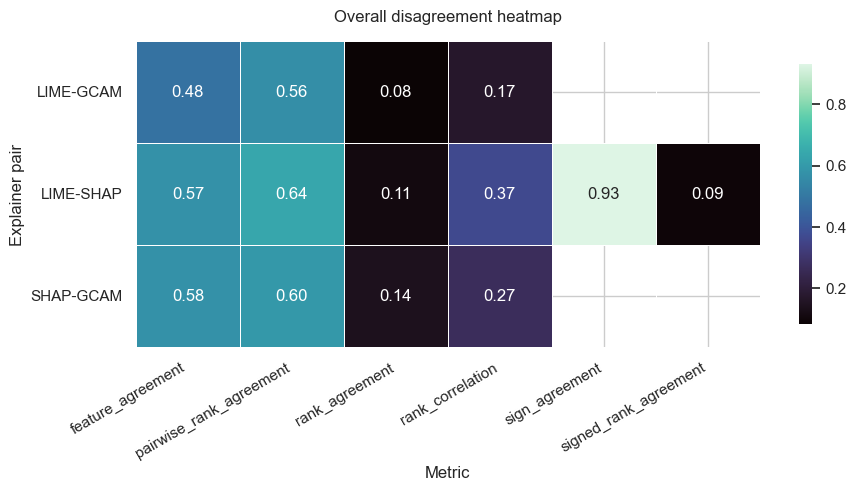

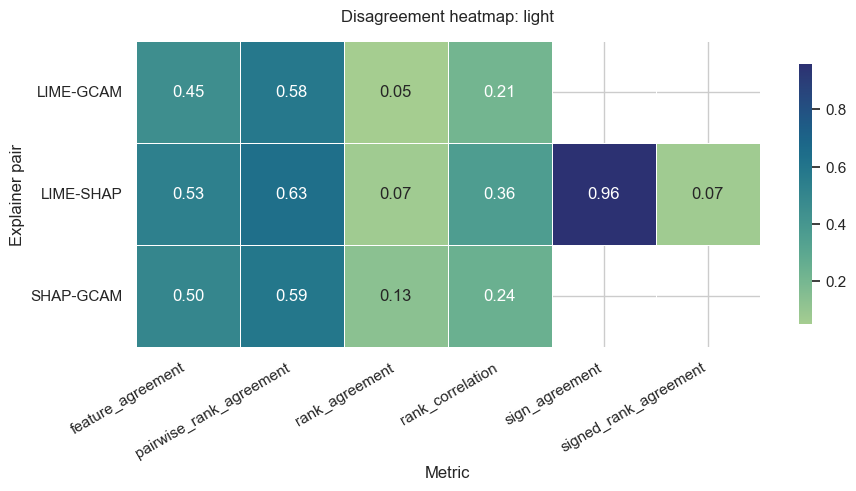

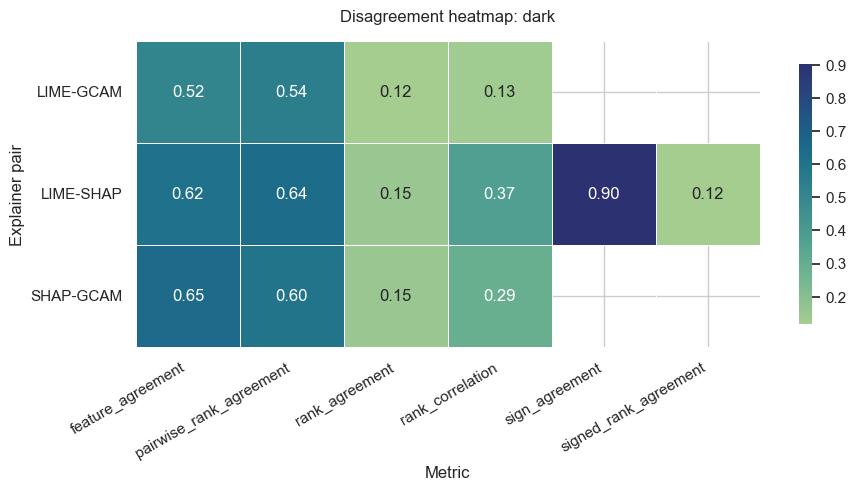

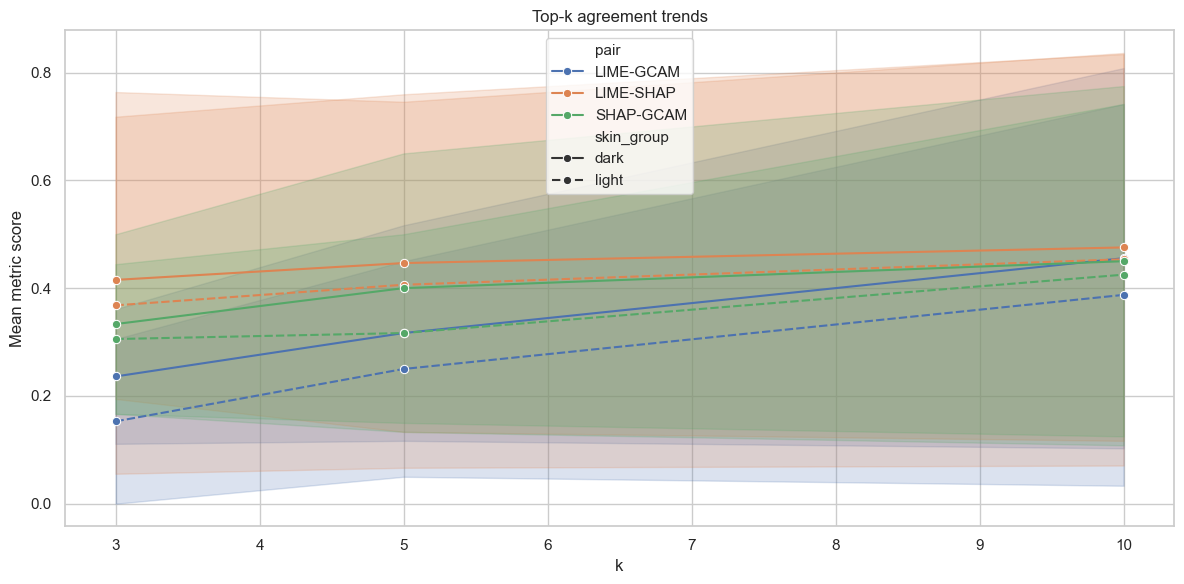

In [21]:
PAIR_LABELS = {
    ("lime", "shap"): "LIME-SHAP",
    ("lime", "gradcam"): "LIME-GCAM",
    ("shap", "gradcam"): "SHAP-GCAM",
}


def make_pair_label(explainer_a, explainer_b):
    return PAIR_LABELS.get((explainer_a, explainer_b), f"{explainer_a.upper()}-{explainer_b.upper()}")


def plot_disagreement_heatmap(heatmap_df, title, cmap):
    plot_df = heatmap_df.copy()
    plot_df["pair"] = plot_df.apply(lambda row: make_pair_label(row["explainer_a"], row["explainer_b"]), axis=1)
    plot_df = plot_df[plot_df["k"].isna() | (plot_df["k"] == 5)]
    pivot_df = plot_df.pivot_table(index="pair", columns="metric", values="mean_score")

    fig_height = max(4.5, 1.2 * len(pivot_df.index))
    fig, ax = plt.subplots(figsize=(13, fig_height))
    sns.heatmap(pivot_df, annot=True, cmap=cmap, fmt=".2f", linewidths=0.5, linecolor="white", cbar_kws={"shrink": 0.85}, ax=ax)

    ax.set_title(title, pad=14)
    ax.set_xlabel("Metric")
    ax.set_ylabel("Explainer pair")
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=11)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
    fig.subplots_adjust(left=0.30, bottom=0.20)
    plt.show()


plot_disagreement_heatmap(overall_summary_df, "Overall disagreement heatmap", "mako")

for skin_group in ["light", "dark"]:
    subgroup_heatmap = summary_df[summary_df["skin_group"] == skin_group].copy()
    plot_disagreement_heatmap(subgroup_heatmap, f"Disagreement heatmap: {skin_group}", "crest")

topk_df = summary_df[summary_df["metric"].isin(["feature_agreement", "rank_agreement", "sign_agreement", "signed_rank_agreement"])].copy()
topk_df["pair"] = topk_df.apply(lambda row: make_pair_label(row["explainer_a"], row["explainer_b"]), axis=1)
plt.figure(figsize=(12, 6))
sns.lineplot(data=topk_df, x="k", y="mean_score", hue="pair", style="skin_group", marker="o")
plt.title("Top-k agreement trends")
plt.ylabel("Mean metric score")
plt.tight_layout()


# Qualitative overlay panel


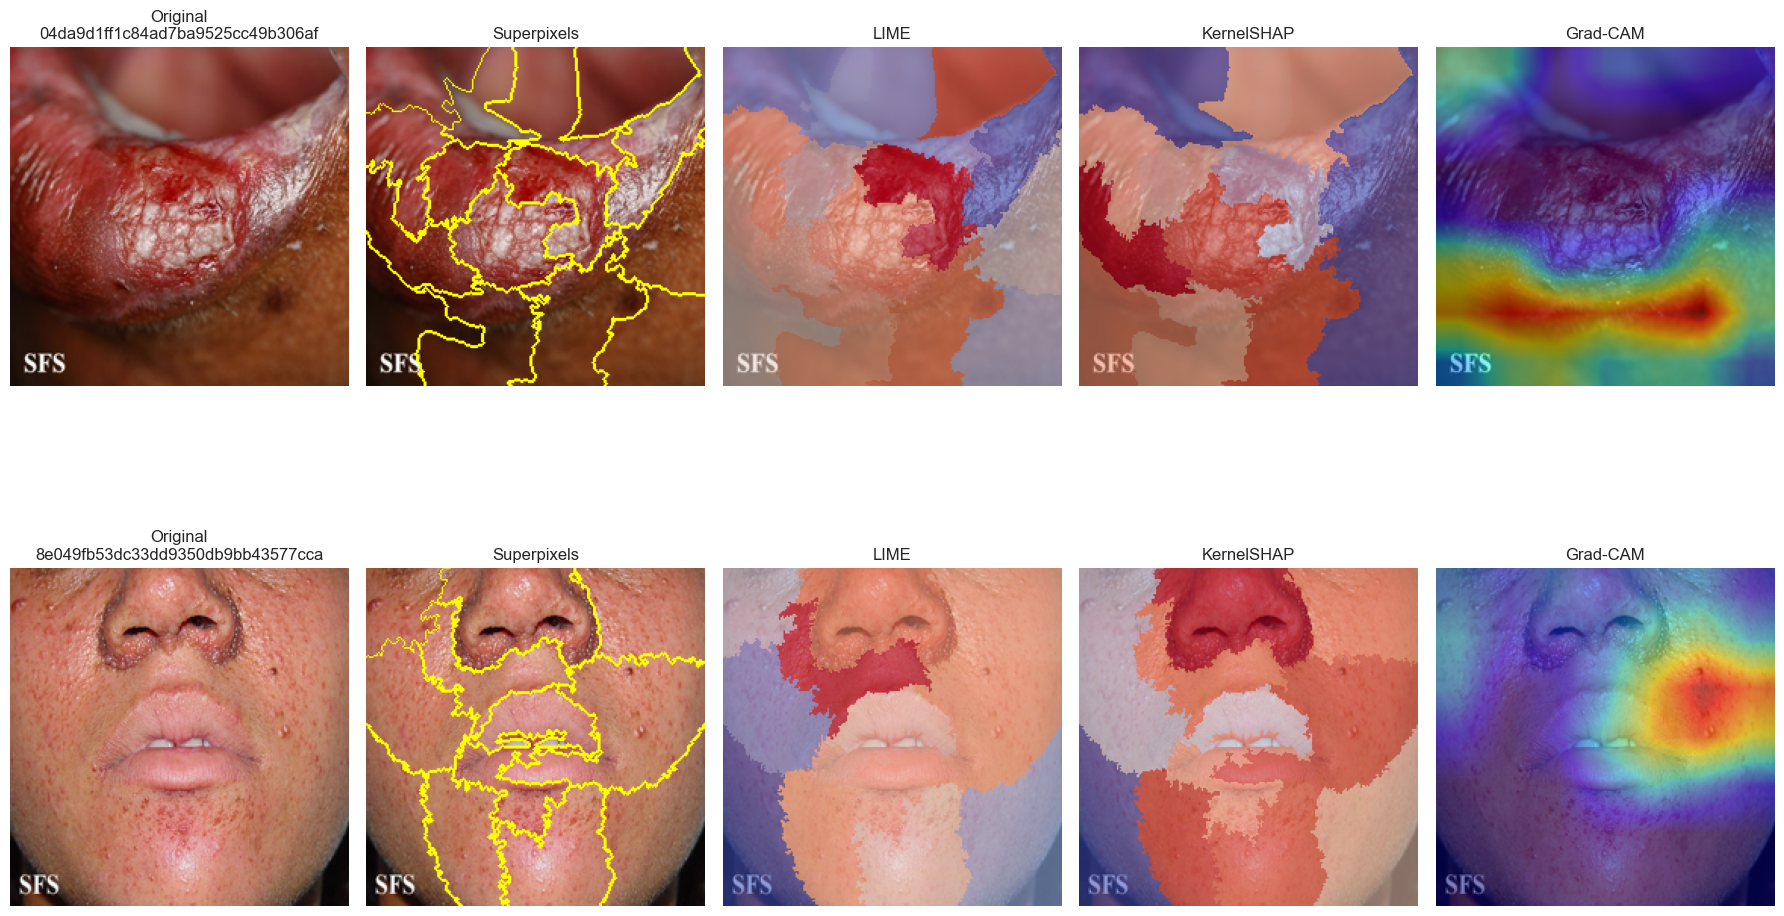

In [22]:
example_ids = list(visual_cache.keys())[:2]
if example_ids:
    fig, axes = plt.subplots(len(example_ids), 5, figsize=(18, 6 * len(example_ids)))
    if len(example_ids) == 1:
        axes = np.expand_dims(axes, axis=0)

    for row_idx, image_id in enumerate(example_ids):
        item = visual_cache[image_id]
        image_np = item["image"]
        segments = item["segments"]
        lime_map = overlay_segment_scores(image_np, segments, item["lime_scores"])
        shap_map = overlay_segment_scores(image_np, segments, item["shap_scores"])
        gradcam_map = item["gradcam_map"]

        axes[row_idx, 0].imshow(image_np)
        axes[row_idx, 0].set_title(f"Original\n{image_id}")

        axes[row_idx, 1].imshow(mark_boundaries(image_np, segments))
        axes[row_idx, 1].set_title("Superpixels")

        axes[row_idx, 2].imshow(image_np)
        axes[row_idx, 2].imshow(lime_map, cmap="coolwarm", alpha=0.55)
        axes[row_idx, 2].set_title("LIME")

        axes[row_idx, 3].imshow(image_np)
        axes[row_idx, 3].imshow(shap_map, cmap="coolwarm", alpha=0.55)
        axes[row_idx, 3].set_title("KernelSHAP")

        axes[row_idx, 4].imshow(image_np)
        axes[row_idx, 4].imshow(gradcam_map, cmap="jet", alpha=0.5)
        axes[row_idx, 4].set_title("Grad-CAM")

        for col_idx in range(5):
            axes[row_idx, col_idx].axis("off")

    plt.tight_layout()
else:
    print("Run the attribution cell first to populate qualitative examples.")


# Single-sample explanation views

Use this section when you want to inspect one sample in more detail. It plots the original image, superpixel boundaries, and then separate LIME, KernelSHAP, and Grad-CAM views one at a time.


In [23]:
list(visual_cache.keys())

['04da9d1ff1c84ad7ba9525cc49b306af',
 '8e049fb53dc33dd9350db9bb43577cca',
 '9e41dfef88af0d8e29fddd91da1f4c5a',
 '510fafefb5d604e4ff52514cfee2956d',
 '849d862189a58f44a063ee6ba1a80b1b',
 '889a8ed4164c01992b4981e78597a29a',
 '7e514cce023d25e1d79f29ccdc563c22',
 '91c13b3c952550f97adc320b51b10557',
 '8aa5fd77a9d10d03e1f10af68f061394',
 '670ca45dcfd987fbafd79d5f9268386d',
 '548ec840d0d93a2e469cd33f6127cd6d',
 '754941078eaae0de5abe363f8ff601e8',
 'f3fd93d48f9b56eb3f739b76bfa34963',
 'aca7d6f50977c69e54dd0113c886edce',
 'ffe62c609421e3adaa69ee1751dd6a37',
 'a3c7b8fe3fd839e2c537b486a8cc701e',
 'b394018dd777aaf58edc5504b52ed1b7',
 'f528a2d620dbe5e3348b3ff18a9f7d52',
 '92f8f7f3126dbb65a601e1734fe4d8c8',
 '5423e2d3ad68054e7b51e27e146fddca',
 '3070b01587b512cd82237be8b2f7db74',
 '6431c31da63b8925dd55956eb4ae62a5',
 '208370a35b3efbf6001a0fde41806609',
 '6fdbddb630dca12051aa46f7da98f732']

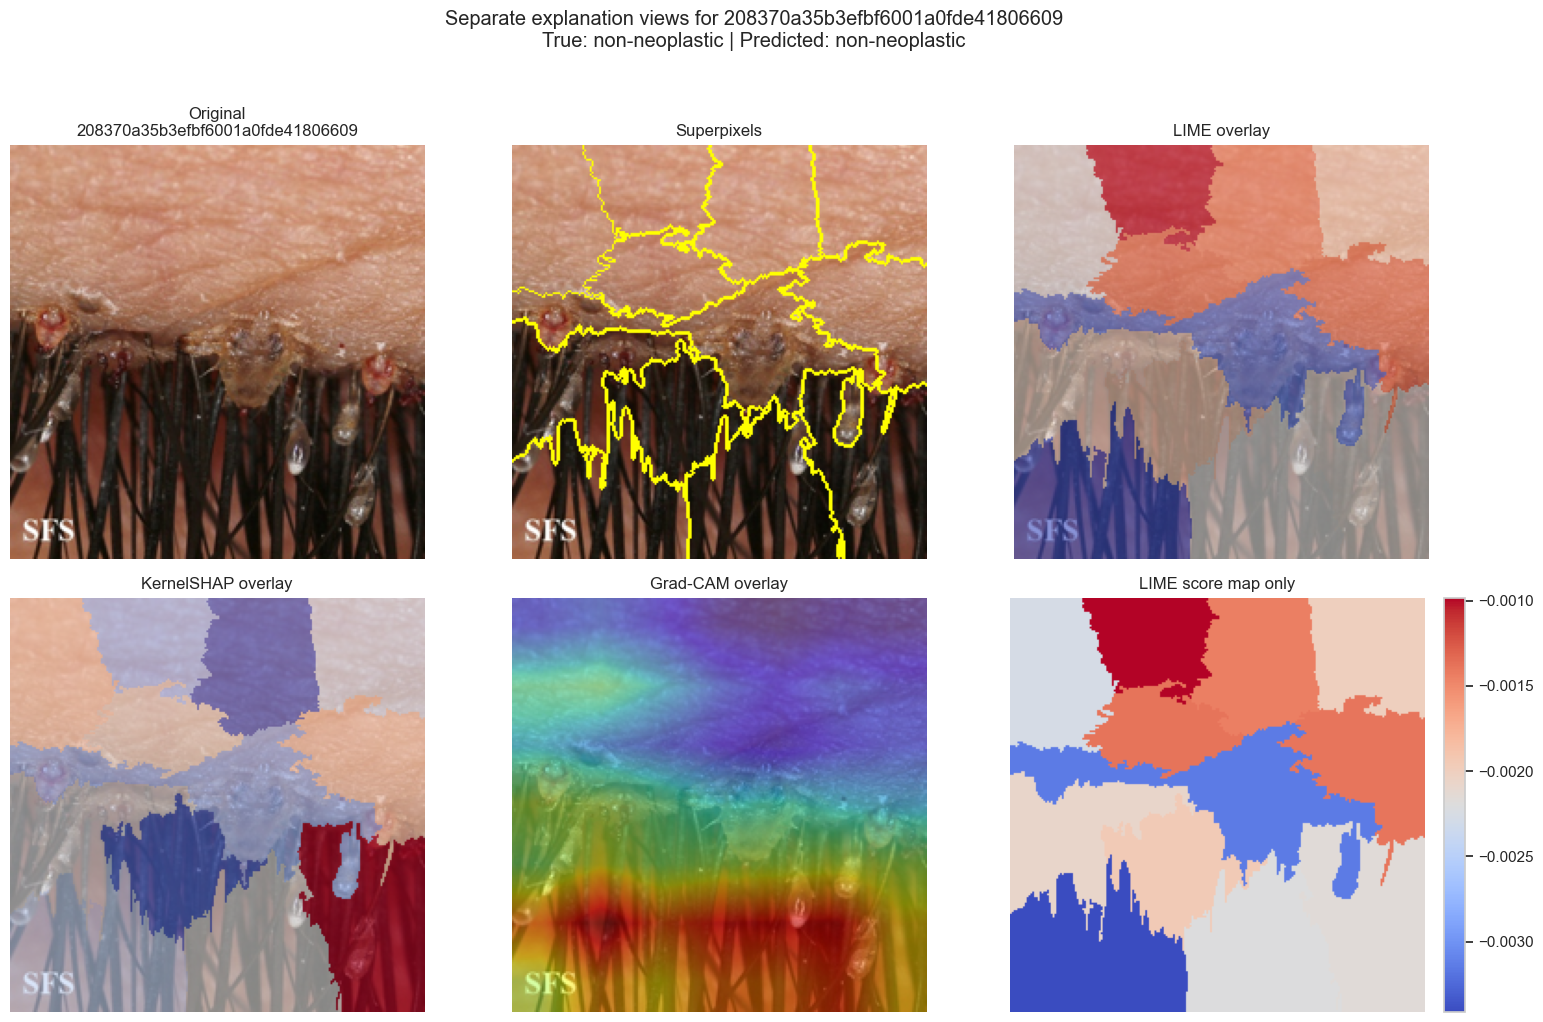

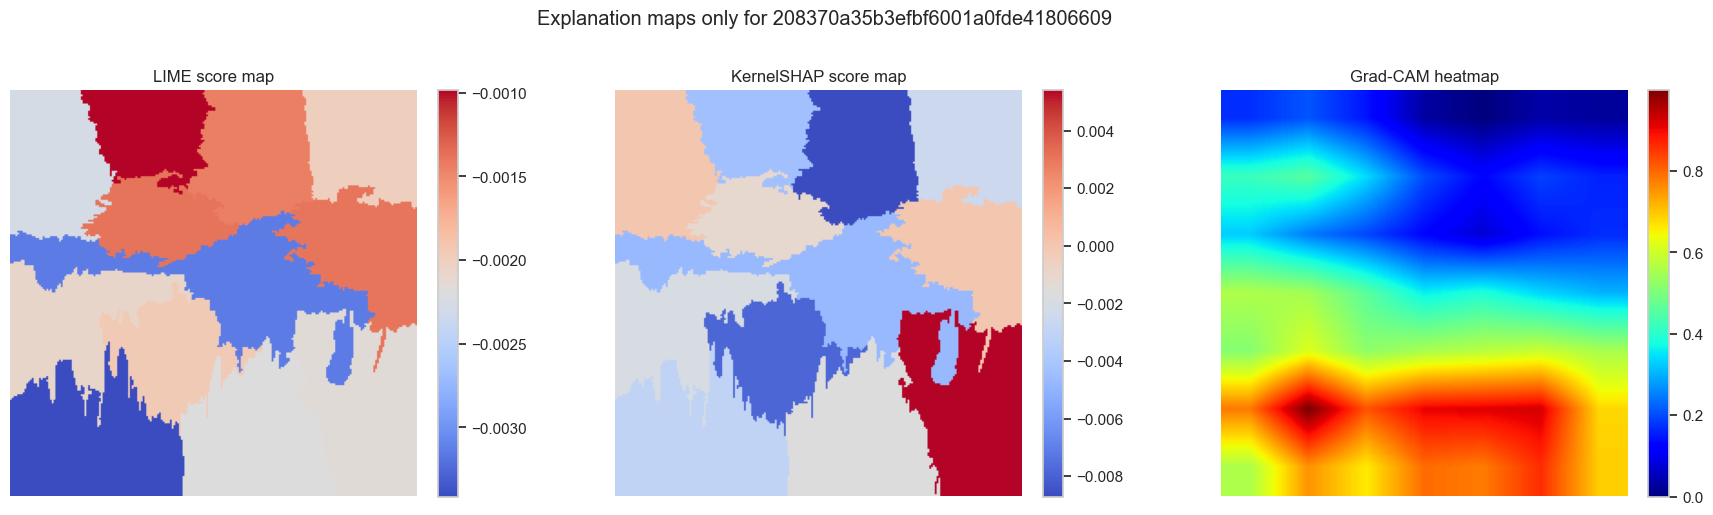

In [24]:
SAMPLE_IMAGE_ID = '208370a35b3efbf6001a0fde41806609'

if SAMPLE_IMAGE_ID is None:
    print("Run the attribution cell first to populate visual_cache.")
else:
    item = visual_cache[SAMPLE_IMAGE_ID]
    image_np = item["image"]
    segments = item["segments"]
    lime_map = overlay_segment_scores(image_np, segments, item["lime_scores"])
    shap_map = overlay_segment_scores(image_np, segments, item["shap_scores"])
    gradcam_map = item["gradcam_map"]

    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()

    axes[0].imshow(image_np)
    axes[0].set_title(f"Original\n{SAMPLE_IMAGE_ID}")
    axes[0].axis("off")

    axes[1].imshow(mark_boundaries(image_np, segments))
    axes[1].set_title("Superpixels")
    axes[1].axis("off")

    axes[2].imshow(image_np)
    axes[2].imshow(lime_map, cmap="coolwarm", alpha=0.60)
    axes[2].set_title("LIME overlay")
    axes[2].axis("off")

    axes[3].imshow(image_np)
    axes[3].imshow(shap_map, cmap="coolwarm", alpha=0.60)
    axes[3].set_title("KernelSHAP overlay")
    axes[3].axis("off")

    axes[4].imshow(image_np)
    axes[4].imshow(gradcam_map, cmap="jet", alpha=0.50)
    axes[4].set_title("Grad-CAM overlay")
    axes[4].axis("off")

    im = axes[5].imshow(lime_map, cmap="coolwarm")
    axes[5].set_title("LIME score map only")
    axes[5].axis("off")
    plt.colorbar(im, ax=axes[5], fraction=0.046, pad=0.04)

    plt.suptitle(
        f"Separate explanation views for {SAMPLE_IMAGE_ID}\nTrue: {item['true_label']} | Predicted: {item['pred_label']}",
        y=1.02,
    )
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    explanation_views = [
        (lime_map, "LIME score map", "coolwarm"),
        (shap_map, "KernelSHAP score map", "coolwarm"),
        (gradcam_map, "Grad-CAM heatmap", "jet"),
    ]

    for ax, (map_data, title, cmap) in zip(axes, explanation_views):
        im = ax.imshow(map_data, cmap=cmap)
        ax.set_title(title)
        ax.axis("off")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.suptitle(f"Explanation maps only for {SAMPLE_IMAGE_ID}", y=1.02)
    plt.tight_layout()
    plt.show()
